In [2]:
import torch
import numpy as np
import pandas as pd
import os 
import re
import torch.nn.functional as F 
import math
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils import clip_grad_norm_
from tensorflow import keras
from tqdm import tqdm
import time 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
device = torch.device('cuda')
print(device)

cuda


In [3]:
def fill_down_excel_files(input_folder, output_folder=None):
    # Check if input folder exists
    if not os.path.exists(input_folder):
        print(f"Error: Input folder '{input_folder}' does not exist.")
        return

    # Create output folder if saving elsewhere
    if output_folder and not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Output folder created: {output_folder}")

    files_processed = 0  # Track processed files

    for file in os.listdir(input_folder):
        if file.endswith(".xlsx") or file.endswith(".xls"):
            input_path = os.path.join(input_folder, file)

            try:
                # Read the file
                df = pd.read_excel(input_path)
                print(f"Processing: {file}")

                # Fill missing values
                df.fillna(method='ffill', inplace=True)

                # Set output path (either overwrite or to a new folder)
                if output_folder:
                    output_path = os.path.join(output_folder, file)
                else:
                    output_path = input_path  # overwrite original file

                # Save the processed file
                df.to_excel(output_path, index=False)
                print(f"Saved: {output_path}")
                files_processed += 1

            except Exception as e:
                print(f"Error processing file '{file}': {e}")

    if files_processed == 0:
        print("No files processed.")
    else:
        print(f"Finished processing {files_processed} files.")

In [4]:
input_folder = r"C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\label_data"
output_folder = r"C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2"

fill_down_excel_files(input_folder, output_folder = output_folder)

Processing: SA06_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA06_label.xlsx
Processing: SA07_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA07_label.xlsx
Processing: SA08_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA08_label.xlsx
Processing: SA09_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA09_label.xlsx
Processing: SA10_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA10_label.xlsx


C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users

Processing: SA11_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA11_label.xlsx
Processing: SA12_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA12_label.xlsx
Processing: SA13_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA13_label.xlsx
Processing: SA14_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA14_label.xlsx
Processing: SA15_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA15_label.xlsx
Processing: SA16_label.xlsx


C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users

Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA16_label.xlsx
Processing: SA17_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA17_label.xlsx
Processing: SA18_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA18_label.xlsx
Processing: SA19_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA19_label.xlsx
Processing: SA20_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA20_label.xlsx
Processing: SA21_label.xlsx


...

C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users

Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA31_label.xlsx
Processing: SA32_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA32_label.xlsx
Processing: SA33_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA33_label.xlsx
Processing: SA35_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA35_label.xlsx
Processing: SA36_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA36_label.xlsx
Processing: SA37_label.xlsx


C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users

Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA37_label.xlsx
Processing: SA38_label.xlsx
Saved: C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2\SA38_label.xlsx
Finished processing 32 files.


C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_13172\60305856.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [5]:
def extract_task_number(task_code):
    # From 'F01 (20)' → '20'
    match = re.search(r'\((\d+)\)', task_code)
    return match.group(1) if match else None

def format_trial_id(trial_id):
    return f"{int(trial_id):02d}"

def get_sensor_filename(folder_id, task_num, trial_id):
    # SA06 → S06
    sensor_folder = "S" + folder_id[2:]
    return f"{sensor_folder}T{task_num}R{trial_id}.csv"

def map_labels_to_sensors(sensor_root, label_root):
    mappings = []

    for label_file in os.listdir(label_root):
        if not label_file.endswith('.xlsx'):  # Assuming label files are Excel format
            continue

        label_path = os.path.join(label_root, label_file)
        df = pd.read_excel(label_path)

        folder_id = label_file.split("_")[0]  # e.g., SA06

        for _, row in df.iterrows():
            task_num = extract_task_number(row['Task Code (Task ID)'])
            trial_id = format_trial_id(row['Trial ID'])

            if task_num is None:
                continue  # skip malformed rows

            sensor_file = get_sensor_filename(folder_id, task_num, trial_id)
            sensor_path = os.path.join(sensor_root, folder_id, sensor_file)

            # Append mapping including the label filename
            mappings.append({
                "sensor_path": sensor_path,
                "label_row": row,
                "label_filename": label_file
            })

    return mappings

def generate_no_fall_mappings(sensor_root):
    mappings = []

    valid_tasks = {f"{i:02d}" for i in range(1, 20)} | {"35", "36"}
    sensor_pattern = re.compile(r"^S\d+T(\d+)R\d+\.csv$")  # Capture Tyy

    for folder_name in os.listdir(sensor_root):
        folder_path = os.path.join(sensor_root, folder_name)

        if not os.path.isdir(folder_path):
            continue

        for filename in os.listdir(folder_path):
            if not filename.endswith('.csv'):
                continue

            match = sensor_pattern.match(filename)
            if not match:
                continue

            task_num = match.group(1)  # This is yy from Tyy
            if task_num not in valid_tasks:
                continue

            sensor_path = os.path.join(folder_path, filename)

            dummy_label_row = pd.Series({
                "Task Code (Task ID)": "NA", "Description" : "No Fall",
                "Trial ID": "N/A"
            })

            mappings.append({
                "sensor_path": sensor_path,
                "label_row": dummy_label_row,
                "label_filename": None
            })

    return mappings



In [6]:
sensor_root = r"C:\Users\Abhishekh\Downloads\Watch - Project\sensor_data -20250708T151158Z-1-001\sensor_data"
label_root = r"C:\Users\Abhishekh\Downloads\Watch - Project\label_data-20250708T151156Z-1-001\labeldata2"
labelled_mappings = map_labels_to_sensors(sensor_root, label_root)
unlabelled_mappings = generate_no_fall_mappings(sensor_root)
mappings = labelled_mappings + unlabelled_mappings

In [7]:
print(len(mappings))
print(mappings)

5075
[{'sensor_path': 'C:\\Users\\Abhishekh\\Downloads\\Watch - Project\\sensor_data -20250708T151158Z-1-001\\sensor_data\\SA06\\S06T20R01.csv', 'label_row': Task Code (Task ID)                                F01 (20)
Description            Forward fall when trying to sit down
Trial ID                                                  1
Fall_onset_frame                                        130
Fall_impact_frame                                       208
Name: 0, dtype: object, 'label_filename': 'SA06_label.xlsx'}, {'sensor_path': 'C:\\Users\\Abhishekh\\Downloads\\Watch - Project\\sensor_data -20250708T151158Z-1-001\\sensor_data\\SA06\\S06T20R02.csv', 'label_row': Task Code (Task ID)                                F01 (20)
Description            Forward fall when trying to sit down
Trial ID                                                  2
Fall_onset_frame                                        184
Fall_impact_frame                                       272
Name: 1, dtype: object, 'lab

In [8]:
def get_dataset_from_mappings(mappings):
    keyword_to_label = {
        "forward": 1,
        "backward": 2,
        "lateral": 3,
        "no fall": 0,
    }

    num_classes = len(keyword_to_label)
    dataset = []

    for entry in mappings:
        sensor_path = entry['sensor_path']
        label_row = entry['label_row']

        try:
            df = pd.read_csv(sensor_path)
        except FileNotFoundError:
            print(f"Missing sensor file: {sensor_path}")
            continue

        # Drop non-sensor columns
        df = df.drop(columns=["TimeStamp(s)", "FrameCounter"], errors='ignore')

        # Fix column count
        current_features = df.shape[1]
        if current_features > 9:
            df = df.iloc[:, :9]  # Truncate
        elif current_features < 9:
            for i in range(9 - current_features):
                df[f"pad_{i}"] = 0.0  # Add zero padding columns

        # Double check
        if df.shape[1] != 9:
            print(f"Still not 9 features: {sensor_path}, shape={df.shape}")
            continue

        # Convert to tensor
        sensor_tensor = torch.tensor(df.values, dtype=torch.float32)

        # Extract label
        description = str(label_row.get("Description", "")).lower()
        matched_label = None
        for keyword, label in keyword_to_label.items():
            if keyword in description:
                matched_label = label
                break

        if matched_label is None:
            print(f"Couldn't find a valid label in: {description}")
            continue

        label_tensor = torch.tensor(matched_label, dtype=torch.long)
        dataset.append((sensor_tensor, label_tensor))

    return dataset


In [9]:
dataset = get_dataset_from_mappings(mappings)

In [10]:
print(dataset[0][0].shape)
print(dataset[0][1])
len(dataset)

torch.Size([536, 9])
tensor(1)


5075

In [11]:
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
import torch

# Dataset wrapper
class TimeSeriesDataset(Dataset):
    def __init__(self, data, labels):
        assert len(data) == len(labels)
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Collate to handle variable-length sequences
def collate_fn(batch):
    xs, ys = zip(*batch)
    seq_lengths = [x.shape[0] for x in xs]
    padded_x = pad_sequence(xs, batch_first=True)  # (B,T,F)
    mask = torch.zeros(padded_x.shape[:2], dtype=torch.bool)
    for i, length in enumerate(seq_lengths):
        mask[i, :length] = 1
    return padded_x, torch.tensor(ys), mask

# Build dataset lists
data   = [entry[0] for entry in dataset]
labels = [entry[1] for entry in dataset]

full_dataset = TimeSeriesDataset(data, labels)

# train/val/test split
test_size = int(0.3 * len(full_dataset))
train_val_size = len(full_dataset) - test_size
train_size = int(0.8 * train_val_size)
val_size = train_val_size - train_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

batch_size = 64  # you can tweak this
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, collate_fn=collate_fn)


In [12]:
from sklearn.model_selection import StratifiedKFold

k_folds = 5
seed = 42
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)

data = [entry[0] for entry in dataset]
labels = [entry[1] for entry in dataset]
full_dataset = TimeSeriesDataset(data, labels)

fold_indices = list(skf.split(data, [label.item() for label in labels]))

In [13]:
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_

# ------------------ Temporal Block ------------------
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=(kernel_size - 1) * dilation, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=(kernel_size - 1) * dilation, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def _crop_to_match(self, x, target):
        if x.size(2) > target.size(2):
            x = x[:, :, :target.size(2)]
        return x

    def forward(self, x):
        out = self.conv1(x)
        out = self._crop_to_match(out, x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self._crop_to_match(out, x)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout(out)

        res = x if self.downsample is None else self.downsample(x)
        res = self._crop_to_match(res, out)

        return self.relu(out + res)


# ------------------ TCN Classifier ------------------
class TCNClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, num_levels=3, hidden_channels=[64,128,256],
                 kernel_size=3, dropout=0.3):
        super().__init__()
        layers = []
        in_ch = input_dim
        for i in range(num_levels):
            out_ch = hidden_channels[i]
            dilation = 2 ** i
            layers.append(
                TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout)
            )
            in_ch = out_ch

        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(hidden_channels[-1], num_classes)
        )

    def forward(self, x, mask=None):
        """
        x: (B, T, F)
        mask: (B, T) boolean tensor, True for valid timesteps
        """
        x = x.transpose(1,2)  # (B, F, T)
        x = self.tcn(x)       # (B, C, T)

        if mask is not None:
            mask = mask.unsqueeze(1).float()  # (B,1,T)
            x = (x * mask).sum(dim=2) / (mask.sum(dim=2) + 1e-8)  # masked average pooling
        else:
            x = x.mean(dim=2)  # standard global average pooling

        return self.fc(x)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = 9       # features per time step
num_classes = 5     # your label classes

model = TCNClassifier(input_dim=input_dim, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for X, y, mask in train_loader:
        X, y, mask = X.to(device), y.to(device), mask.to(device)   # move mask to GPU
        optimizer.zero_grad()
        outputs = model(X, mask)                                   # pass mask to model
        loss = criterion(outputs, y)
        loss.backward()
        
        # gradient clipping
        clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        
        running_loss += loss.item()
        
        # Compute training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += y.size(0)
        correct_train += (predicted == y).sum().item()
    
    scheduler.step()
    
    # validation
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for X, y, mask in val_loader:
            X, y, mask = X.to(device), y.to(device), mask.to(device)
            outputs = model(X, mask)                                # pass mask to model
            loss = criterion(outputs, y)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += y.size(0)
            correct_val += (predicted == y).sum().item()
    
    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {running_loss/len(train_loader):.4f}, "
          f"Train Acc: {100*correct_train/total_train:.2f}%, "
          f"Val Loss: {val_loss/len(val_loader):.4f}, "
          f"Val Acc: {100*correct_val/total_val:.2f}%")


Epoch 1/50, Train Loss: 0.6975, Train Acc: 78.36%, Val Loss: 0.2062, Val Acc: 94.09%
Epoch 2/50, Train Loss: 0.2130, Train Acc: 93.24%, Val Loss: 0.1763, Val Acc: 95.22%
Epoch 3/50, Train Loss: 0.1353, Train Acc: 95.71%, Val Loss: 0.1201, Val Acc: 96.77%
Epoch 4/50, Train Loss: 0.0892, Train Acc: 97.57%, Val Loss: 0.0798, Val Acc: 97.75%
Epoch 5/50, Train Loss: 0.0714, Train Acc: 97.99%, Val Loss: 0.0799, Val Acc: 97.75%
Epoch 6/50, Train Loss: 0.0661, Train Acc: 98.21%, Val Loss: 0.0593, Val Acc: 98.03%
Epoch 7/50, Train Loss: 0.0539, Train Acc: 98.52%, Val Loss: 0.0625, Val Acc: 98.31%
Epoch 8/50, Train Loss: 0.0494, Train Acc: 98.59%, Val Loss: 0.0643, Val Acc: 98.17%
Epoch 9/50, Train Loss: 0.0469, Train Acc: 98.77%, Val Loss: 0.1036, Val Acc: 96.91%
Epoch 10/50, Train Loss: 0.0377, Train Acc: 99.12%, Val Loss: 0.0580, Val Acc: 98.31%
Epoch 11/50, Train Loss: 0.0305, Train Acc: 99.05%, Val Loss: 0.0366, Val Acc: 98.59%
Epoch 12/50, Train Loss: 0.0260, Train Acc: 99.26%, Val Loss: 0

KeyboardInterrupt: 

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# input_dim = 9       # features per time step
# num_classes = 5     # your label classes

# model = TCNClassifier(input_dim=input_dim, num_classes=num_classes).to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

# num_epochs = 50

# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0
#     correct_train = 0
#     total_train = 0
    
#     for X, y, mask in train_loader:
#         X, y = X.to(device), y.to(device)
#         optimizer.zero_grad()
#         outputs = model(X)
#         loss = criterion(outputs, y)
#         loss.backward()
#         optimizer.step()
        
#         running_loss += loss.item()
        
#         # Compute training accuracy
#         _, predicted = torch.max(outputs.data, 1)
#         total_train += y.size(0)
#         correct_train += (predicted == y).sum().item()
    
#     scheduler.step()
    
#     # validation
#     model.eval()
#     val_loss = 0.0
#     correct_val = 0
#     total_val = 0
#     with torch.no_grad():
#         for X, y, mask in val_loader:
#             X, y = X.to(device), y.to(device)
#             outputs = model(X)
#             loss = criterion(outputs, y)
#             val_loss += loss.item()
            
#             _, predicted = torch.max(outputs.data, 1)
#             total_val += y.size(0)
#             correct_val += (predicted == y).sum().item()
    
#     print(f"Epoch {epoch+1}/{num_epochs}, "
#           f"Train Loss: {running_loss/len(train_loader):.4f}, "
#           f"Train Acc: {100*correct_train/total_train:.2f}%, "
#           f"Val Loss: {val_loss/len(val_loader):.4f}, "
#           f"Val Acc: {100*correct_val/total_val:.2f}%")


In [15]:
counters = [0, 0, 0, 0, 0]
for y in labels:
    counters[y.item()] += 1
    

print(counters)

[2729, 1241, 474, 631, 0]


In [16]:
def test_model(model, test_loader, criterion, device='cpu'):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y, mask in test_loader:  # get mask from DataLoader
            x, y, mask = x.to(device), y.to(device), mask.to(device)

            output = model(x, mask)     # pass mask here
            loss = criterion(output, y)
            test_loss += loss.item()

            preds = torch.argmax(output, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

            all_preds.append(preds.cpu())
            all_targets.append(y.cpu())

    avg_loss = test_loss / len(test_loader)
    accuracy = correct / total

    print(f"\n Test Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.4f}")

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'predictions': torch.cat(all_preds),
        'targets': torch.cat(all_targets)
    }


In [17]:
test_result = test_model(model, test_loader, criterion, device=device)



 Test Loss: 0.0284 | Test Accuracy: 0.9954


In [18]:
def plot_confusion_matrix(preds, targets, class_names=None, normalize=False, title='Confusion Matrix'):
    cm = confusion_matrix(targets, preds, normalize='true' if normalize else None)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, cmap='Blues', values_format=".2f" if normalize else "d")
    ax.set_title(title)
    plt.show()

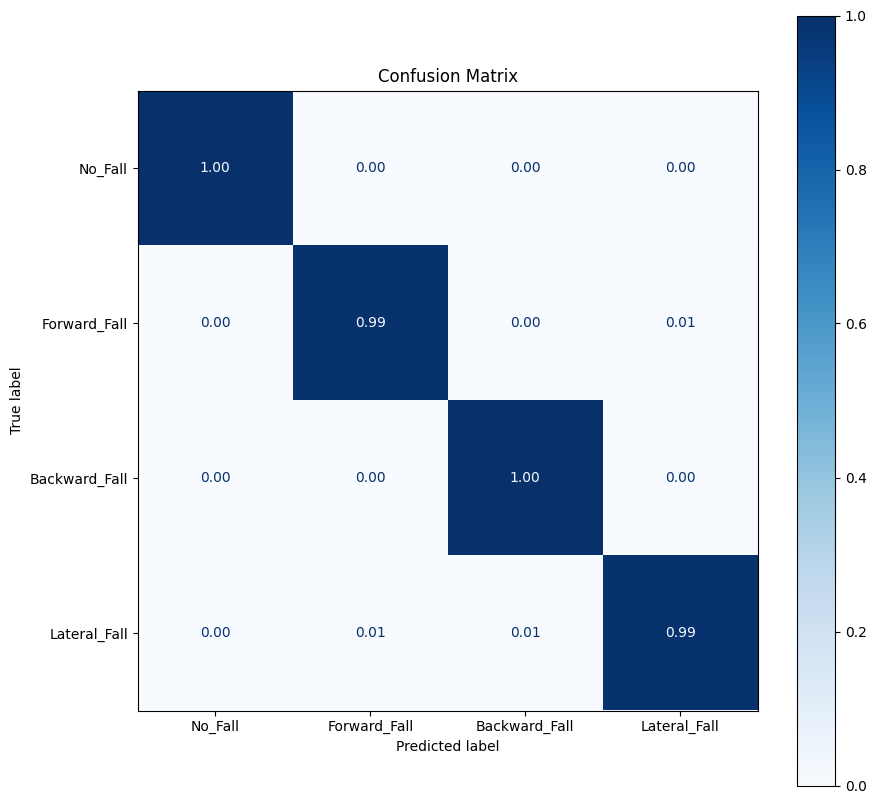

In [19]:
# Get raw predictions and targets
preds = test_result['predictions'].numpy()
targets = test_result['targets'].numpy()

# Optional: list your class labels if available
class_names = ['No_Fall', 'Forward_Fall', 'Backward_Fall', 'Lateral_Fall']

# Plot it
plot_confusion_matrix(preds, targets, class_names=class_names, normalize=True)

In [21]:
load_path = "/root/checkpoints/run_20250504-234707/checkpoint_epoch_10.pth"
model

LSTMClassifier(
  (lstm): LSTM(9, 32, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=32, out_features=5, bias=True)
)

In [22]:
model.lstm


LSTM(9, 32, num_layers=2, batch_first=True, dropout=0.3)

In [23]:
# Load state dict
state_dict = torch.load(load_path, map_location="cpu")

# Inspect keys
print(state_dict.keys())

print(state_dict['model_state_dict'].keys())


C:\Users\Abhishekh\AppData\Local\Temp\ipykernel_22372\2192677237.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(load_path, map_location="cpu")


FileNotFoundError: [Errno 2] No such file or directory: '/root/checkpoints/run_20250504-234707/checkpoint_epoch_10.pth'

In [278]:

# Load checkpoint
checkpoint = torch.load(load_path, map_location="cpu")

# Get model weights only
model_state_dict = checkpoint['model_state_dict']

# Example: get LSTM layer 0 parameters
weight_ih_l0 = model_state_dict['lstm.weight_ih_l0'].numpy()
weight_hh_l0 = model_state_dict['lstm.weight_hh_l0'].numpy()
bias_ih_l0   = model_state_dict['lstm.bias_ih_l0'].numpy()
bias_hh_l0   = model_state_dict['lstm.bias_hh_l0'].numpy()

# Example: for FC layer
fc_weight = model_state_dict['fc.weight'].numpy()
fc_bias   = model_state_dict['fc.bias'].numpy()

In [279]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Disable GPU to prevent cuDNN usage during conversion
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # Force CPU usage

def convert_pytorch_multilayer_lstm_to_keras(state_dict, input_size, hidden_size, num_layers, output_size=None):
    # Define Keras model using Functional API for single time step
    input_data = layers.Input(batch_shape=(1, 1, input_size), name='input')
    
    # Inputs for hidden and cell states for each LSTM layer
    state_inputs = []
    for i in range(num_layers):
        state_inputs.append([
            layers.Input(batch_shape=(1, hidden_size), name=f'hidden_state_{i}'),
            layers.Input(batch_shape=(1, hidden_size), name=f'cell_state_{i}')
        ])
    
    # Create LSTM layers with implementation=1 and unroll=True
    x = input_data
    new_states = []
    for i in range(num_layers):
        return_sequences = True if i < num_layers - 1 else False
        lstm_layer = layers.LSTM(hidden_size,
                                return_sequences=return_sequences,
                                return_state=True,
                                implementation=1,  # Force standard TensorFlow LSTM
                                unroll=True,      # Unroll for TFLite compatibility
                                name=f'lstm_{i}')
        x, h, c = lstm_layer(x, initial_state=state_inputs[i])
        new_states.append([h, c])
    
    # Add Dense layer with softmax
    if output_size is not None:
        x = layers.Dense(output_size, activation='softmax', name='dense')(x)
    
    # Define model
    outputs = [x] + [state for layer_states in new_states for state in layer_states]
    model = models.Model(
        inputs=[input_data] + [state for layer_states in state_inputs for state in layer_states],
        outputs=outputs
    )
    
    # Load PyTorch weights
    for i in range(num_layers):
        lstm_layer = model.get_layer(f'lstm_{i}')
        weight_ih = state_dict[f'lstm.weight_ih_l{i}'].cpu().numpy().T
        weight_hh = state_dict[f'lstm.weight_hh_l{i}'].cpu().numpy().T
        bias_ih = state_dict[f'lstm.bias_ih_l{i}'].cpu().numpy()
        bias_hh = state_dict[f'lstm.bias_hh_l{i}'].cpu().numpy()
        bias = bias_ih + bias_hh
        lstm_layer.set_weights([weight_ih, weight_hh, bias])
    
    if output_size is not None:
        fc_layer = model.get_layer('dense')
        fc_weight = state_dict['fc.weight'].cpu().numpy().T
        fc_bias = state_dict['fc.bias'].cpu().numpy()
        fc_layer.set_weights([fc_weight, fc_bias])
    
    return model

def convert_keras_to_tflite(keras_model, tflite_path):
    # Debug: Inspect model operations
    
   
    # Convert to TFLite with float16 inputs/outputs
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    # converter.inference_input_type = tf.float16  # Enforce float16 inputs
    # converter.inference_output_type = tf.float16  # Enforce float16 outputs
    converter.experimental_new_converter = True
    try:
        tflite_model = converter.convert()
    except Exception as e:
        print(f"TFLite conversion failed: {e}")
        raise
    
    # Save TFLite model
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f"TFLite model saved to {tflite_path}")

In [ ]:

# Example parameters (replace with your model's parameters)
input_size = 9
hidden_size = 32
num_layers = 2
output_size = 5

# Dummy state_dict for demonstration (replace with your PyTorch state_dict)
state_dict = model_state_dict 

# Convert PyTorch to Keras
keras_model = convert_pytorch_multilayer_lstm_to_keras(
    state_dict, input_size, hidden_size, num_layers, output_size
)

# Convert Keras to TFLite
# input_dim = 9
# hidden_dim = 32           # ↑ Increase hidden size for better capacity on timeseries
# num_layers = 2              # Fine for now — could test 3 later
# dropout = 0.3  


NameError: name 'model_state_dict' is not defined

In [281]:
keras_model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (1, 1, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_state_0      │ (1, 32)           │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cell_state_0        │ (1, 32)           │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ [(1, 1, 32), (1,  │      5,376 │ input[0][0],      │
│                     │ 32), (1, 32)]     │            │ hidden_state_0[0… │
│                     │                   │            │ cell_state_0[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_state_1      │ (1, 32)           │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cell_state_1        │ (1, 32)           │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(1, 32), (1,     │      8,320 │ lstm_0[0][0],     │
│                     │ 32), (1, 32)]     │            │ hidden_state_1[0… │
│                     │                   │            │ cell_state_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (1, 5)            │        165 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,861 (54.14 KB)

 Trainable params: 13,861 (54.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def compare_models(pytorch_model, keras_model, input_data, h0, c0):
    # PyTorch inference (model on GPU)
    pytorch_model.eval()
    with torch.no_grad():
        pytorch_output = pytorch_model(
            torch.tensor(input_data, dtype=torch.float32).cuda(),
            mask = None
        )
        pytorch_output = nn.functional.softmax(pytorch_output)
        pytorch_output = pytorch_output.cpu().numpy()
     
    
    # Keras inference
    keras_inputs = [input_data] + [h0[i] for i in range(len(h0))] + [c0[i] for i in range(len(c0))]
    keras_outputs = keras_model.predict(keras_inputs, verbose=0)
    keras_output = keras_outputs[0]

    
    # Compare outputs
    print("Output Comparison (PyTorch vs Keras):")
    print(f"PyTorch Output Shape: {pytorch_output.shape}, Keras Output Shape: {keras_output.shape}")
    output_diff = np.abs(pytorch_output - keras_output).max()
    print(f"Max Output Difference: {output_diff}")
    print(keras_output)
    print(pytorch_output)
    #conversion of keras model to .tflite model 


In [284]:
# Prepare sample input and initial states
input_data = np.random.randn(1, 1, input_size).astype(np.float32)  # (batch, time_steps, input_size)
h0 = [np.zeros((1, hidden_size), dtype=np.float16) for _ in range(num_layers)]  # (num_layers, batch, hidden_size)
c0 = [np.zeros((1, hidden_size), dtype=np.float16) for _ in range(num_layers)]  # (num_layers, batch, hidden_size)

# Compare outputs
compare_models(model, keras_model, input_data, h0, c0)

Output Comparison (PyTorch vs Keras):
PyTorch Output Shape: (1, 5), Keras Output Shape: (1, 5)
Max Output Difference: 0.009826719760894775
[[0.14574616 0.25740355 0.18706664 0.21048354 0.19930011]]
[[0.14538656 0.26723027 0.18339652 0.2030109  0.20097573]]


/tmp/ipykernel_20493/72629114.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  pytorch_output = nn.functional.softmax(pytorch_output)


In [285]:
tf_lite_path = "/root/tflite/model.tflite"


In [286]:
convert_keras_to_tflite(keras_model, tf_lite_path)

INFO:tensorflow:Assets written to: /tmp/tmpr2heaup6/assets


INFO:tensorflow:Assets written to: /tmp/tmpr2heaup6/assets


Saved artifact at '/tmp/tmpr2heaup6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(1, 1, 9), dtype=tf.float32, name='input'), TensorSpec(shape=(1, 32), dtype=tf.float32, name='hidden_state_0'), TensorSpec(shape=(1, 32), dtype=tf.float32, name='cell_state_0'), TensorSpec(shape=(1, 32), dtype=tf.float32, name='hidden_state_1'), TensorSpec(shape=(1, 32), dtype=tf.float32, name='cell_state_1')]
Output Type:
  List[TensorSpec(shape=(1, 5), dtype=tf.float32, name=None), TensorSpec(shape=(1, 32), dtype=tf.float32, name=None), TensorSpec(shape=(1, 32), dtype=tf.float32, name=None), TensorSpec(shape=(1, 32), dtype=tf.float32, name=None), TensorSpec(shape=(1, 32), dtype=tf.float32, name=None)]
Captures:
  128988266906192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128988267281424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128988267276848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  128988267281952: Ten

W0000 00:00:1746383138.619857   20493 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1746383138.619873   20493 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-04 23:55:38.620015: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpr2heaup6
2025-05-04 23:55:38.620539: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-04 23:55:38.620546: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpr2heaup6
2025-05-04 23:55:38.625526: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-04 23:55:38.649566: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpr2heaup6
2025-05-04 23:55:38.658819: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 38806 microseconds.
2025-05-04 23:55:38.730230: I tensorflow/comp

In [289]:
import os
import numpy as np
import tensorflow as tf

# Disable GPU to avoid CUDA warnings
os.environ['CUDA_VISIBLE_DEVICES'] = ''

def run_tflite_inference(model_path, input_data, hidden_states, cell_states):
    """
    Run inference on a TFLite model.
    
    Args:
        model_path (str): Path to the TFLite model file.
        input_data (np.ndarray): Input data of shape (1, 1, 9).
        hidden_states (list): List of hidden states [(1, 128), (1, 128)] for 2 LSTM layers.
        cell_states (list): List of cell states [(1, 128), (1, 128)] for 2 LSTM layers.
    
    Returns:
        dict: Dictionary containing prediction and new LSTM states.
    """
    # Validate inputs
    if input_data.shape != (1, 1, 9):
        raise ValueError(f"Expected input_data shape (1, 1, 9), got {input_data.shape}")
    if len(hidden_states) != 2 or len(cell_states) != 2:
        raise ValueError("Expected 2 hidden and 2 cell states for 2 LSTM layers")
    for i, (h, c) in enumerate(zip(hidden_states, cell_states)):
        if h.shape != (1, 32) or c.shape != (1,32):
            raise ValueError(f"Expected state shape (1, 128) for layer {i}, got h={h.shape}, c={c.shape}")

    # Load TFLite model
    try:
        interpreter = tf.lite.Interpreter(model_path=model_path)
        interpreter.allocate_tensors()
    except Exception as e:
        raise RuntimeError(f"Failed to load TFLite model: {e}")

    # Get input and output details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Print details for debugging
    print("Input Details:")
    for d in input_details:
        print(f"  {d['name']}: shape={d['shape']}, dtype={d['dtype']}")
    print("Output Details:")
    for i, d in enumerate(output_details):
        print(f"  {i}: shape={d['shape']}, dtype={d['dtype']}")

    # Verify input details
    expected_inputs = 5  # 1 data + 2 hidden + 2 cell states
    if len(input_details) != expected_inputs:
        raise ValueError(f"Expected {expected_inputs} input tensors, got {len(input_details)}")

    # Set input tensors (float32)
    interpreter.set_tensor(input_details[0]['index'], input_data.astype(np.float32))
    for i in range(2):
        interpreter.set_tensor(input_details[1 + i*2]['index'], hidden_states[i].astype(np.float32))
        interpreter.set_tensor(input_details[2 + i*2]['index'], cell_states[i].astype(np.float32))

    # Run inference
    try:
        interpreter.invoke()
    except Exception as e:
        raise RuntimeError(f"Inference failed: {e}")

    # Find the (1, 5) output tensor (softmax prediction)
    prediction_idx = None
    for i, d in enumerate(output_details):
        if d['shape'].tolist() == [1, 5]:
            prediction_idx = i
            break
    if prediction_idx is None:
        raise ValueError("No output tensor with shape (1, 5) found")

    # Get outputs
    prediction = interpreter.get_tensor(output_details[prediction_idx]['index'])  # (1, 5)
    new_hidden_states = [
        interpreter.get_tensor(output_details[(i*2 + 1) % len(output_details)]['index']) for i in range(2)  # (1, 128)
    ]
    new_cell_states = [
        interpreter.get_tensor(output_details[(i*2 + 2) % len(output_details)]['index']) for i in range(2)  # (1, 128)
    ]

    # Validate softmax output
    if not np.all(prediction >= 0) or not np.all(prediction <= 1) or not np.isclose(np.sum(prediction), 1.0, rtol=1e-3):
        print("Warning: Prediction is not a valid softmax output")

    return {
        'prediction': prediction,
        'new_hidden_states': new_hidden_states,
        'new_cell_states': new_cell_states
    }

if __name__ == "__main__":
    # Model and input parameters
    model_path = "/root/tflite/model.tflite"
    
    try:
        # Generate synthetic input data
        input_data = np.random.randn(1, 1, 9).astype(np.float32)  # Random data
        # Alternative: fixed data for reproducibility
        # input_data = np.array([[[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]]], dtype=np.float32)
        
        # Initialize LSTM states
        hidden_states = [np.zeros((1, 32), dtype=np.float32) for _ in range(2)]
        cell_states = [np.zeros((1, 32), dtype=np.float32) for _ in range(2)]
        
        # Run inference
        results = run_tflite_inference(model_path, input_data, hidden_states, cell_states)
        
        # Print results
        print("Softmax Prediction:", results['prediction'])
        print("Predicted Class:", np.argmax(results['prediction']))
        
        # Optionally print new states (uncomment for debugging)
        # for i, (h, c) in enumerate(zip(results['new_hidden_states'], results['new_cell_states'])):
        #     print(f"Layer {i} New Hidden State Shape:", h.shape)
        #     print(f"Layer {i} New Cell State Shape:", c.shape)
        
    except Exception as e:
        print(f"Error: {e}")

Input Details:
  serving_default_input:0: shape=[1 1 9], dtype=<class 'numpy.float32'>
  serving_default_cell_state_1:0: shape=[ 1 32], dtype=<class 'numpy.float32'>
  serving_default_hidden_state_0:0: shape=[ 1 32], dtype=<class 'numpy.float32'>
  serving_default_hidden_state_1:0: shape=[ 1 32], dtype=<class 'numpy.float32'>
  serving_default_cell_state_0:0: shape=[ 1 32], dtype=<class 'numpy.float32'>
Output Details:
  0: shape=[ 1 32], dtype=<class 'numpy.float32'>
  1: shape=[ 1 32], dtype=<class 'numpy.float32'>
  2: shape=[ 1 32], dtype=<class 'numpy.float32'>
  3: shape=[1 5], dtype=<class 'numpy.float32'>
  4: shape=[ 1 32], dtype=<class 'numpy.float32'>
Softmax Prediction: [[0.13484833 0.26137018 0.1885966  0.22293481 0.1922501 ]]
Predicted Class: 1
